In [1]:
import pandas as pd
stk_data = pd.read_csv(r'D:\HopeAI\Assignments\12. Time_Series\SBIN_data.csv', parse_dates=True, index_col='Date')
stk_data


,Close,High,Low,Open,Volume
Date,,,,,
2024-01-01,618.355835,623.706899,615.125965,619.175395,8295548
2024-01-02,616.523987,624.767434,611.124727,618.355831,15164482
2024-01-03,620.380554,624.767412,613.004804,616.427515,14571772
2024-01-04,619.705627,623.224788,615.752647,619.464591,13883388
2024-01-05,618.934387,628.383019,614.884957,621.875025,15984585
...,...,...,...,...,...
2024-12-24,796.065369,809.936860,793.271493,808.025232,10602771
2024-12-26,796.457520,806.652767,792.095103,796.996681,8318714
2024-12-27,783.909485,802.192337,781.507699,800.231706,10649800


In [2]:
stk_data = stk_data[['Open', 'High', 'Low', 'Close']]
stk_data


,Open,High,Low,Close
Date,,,,
2024-01-01,619.175395,623.706899,615.125965,618.355835
2024-01-02,618.355831,624.767434,611.124727,616.523987
2024-01-03,616.427515,624.767412,613.004804,620.380554
2024-01-04,619.464591,623.224788,615.752647,619.705627
2024-01-05,621.875025,628.383019,614.884957,618.934387
...,...,...,...,...
2024-12-24,808.025232,809.936860,793.271493,796.065369
2024-12-26,796.996681,806.652767,792.095103,796.457520
2024-12-27,800.231706,802.192337,781.507699,783.909485


In [3]:
from sklearn.preprocessing import MinMaxScaler
min_scale = MinMaxScaler()

training_size = round(len(stk_data) * 0.80)
column="Close"

train_data = stk_data[:training_size]
test_data = stk_data[training_size:]

X_train= min_scale.fit_transform(train_data[[column]])
y_test= min_scale.transform(test_data[[column]])
print("Len X_train:",X_train.shape, "Len y_test:",y_test.shape)


Len X_train: (197, 1) Len y_test: (49, 1)


In [4]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from stockFunctions import rmsemape

trends = ['n', 'c', 't', 'ct']
trend_meaning = {
    'n': 'No constant, no trend (mean = 0)',
    'c': 'Constant only (fixed mean)',
    't': 'Linear time trend only',
    'ct': 'Constant + linear time trend'
}

lags = [1, 2, 3, 4]
results = []

for lag in lags:
    # print("\n************")
    # print(f"Lag: {lag}")
    for trend in trends:
        
        # print(f"Trend: {trend}")
        model = AutoReg(X_train, lags=lag,trend=trend)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(stk_data)-1)
        rmse, mape = rmsemape(y_test,y_pred)
        results.append({
            "lag": lag,
            "trend": trend,
            "rmse": rmse,
            "mape": mape
        })
# print("\n************")

# Convert to DataFrame
results_df = pd.DataFrame(results)
# print(results_df)
# Rank by RMSE first
top_models = results_df.sort_values("rmse").head(3).round(4)
print('Top 3 models:', top_models)
# Pick lowest MAPE among top RMSE models
best_model = top_models.loc[top_models["mape"].idxmin()]

print("Best Model using RMSE primary, MAPE secondary")
print(best_model)


Top 3 models:     lag trend    rmse    mape
15    4    ct  0.0792  0.0920
12    4     n  0.0794  0.0933
8     3     n  0.0796  0.0935
Best Model using RMSE primary, MAPE secondary
lag           4
trend        ct
rmse     0.0792
mape      0.092
Name: 15, dtype: object


In [5]:
model = AutoReg(X_train, lags=best_model['lag'],trend=best_model['trend'])
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(stk_data)-1)
rmse, mape = rmsemape(y_test, y_pred)
print(f'Lag : {lag}, Trend : {trend}')
print(f'RMSE : {rmse:.4f} \nMaPe : {mape:.4f}')


Lag : 4, Trend : ct
RMSE : 0.0792 
MaPe : 0.0920


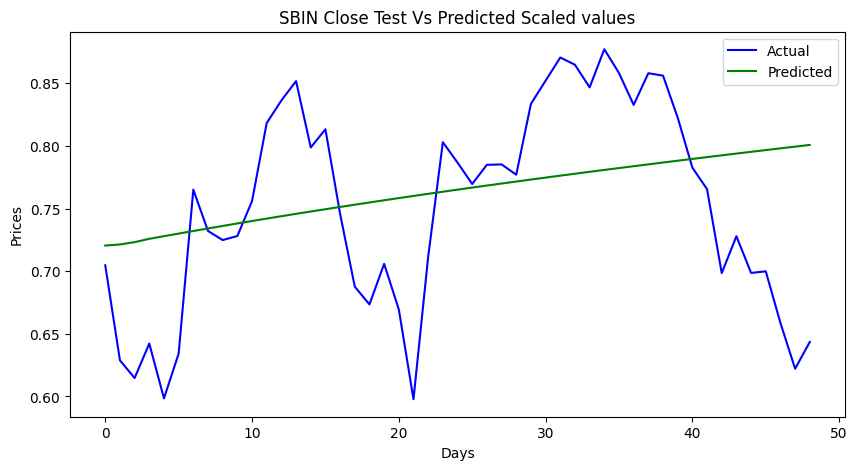

In [6]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","SBIN Close Test Vs Predicted Scaled values","Days","Prices")


In [7]:
y_pred_df = pd.DataFrame(y_pred, columns=[column])
actual_y_pred = min_scale.inverse_transform(y_pred_df)
actual_y_pred_df = pd.DataFrame(actual_y_pred, columns=[column], index = test_data.index)
actual_y_pred_df


,Close
Date,
2024-10-21,802.722248
2024-10-22,802.984271
2024-10-23,803.547754
2024-10-24,804.355982
2024-10-25,804.996158
2024-10-28,805.627296
2024-10-29,806.251190
2024-10-30,806.873011
2024-10-31,807.484883


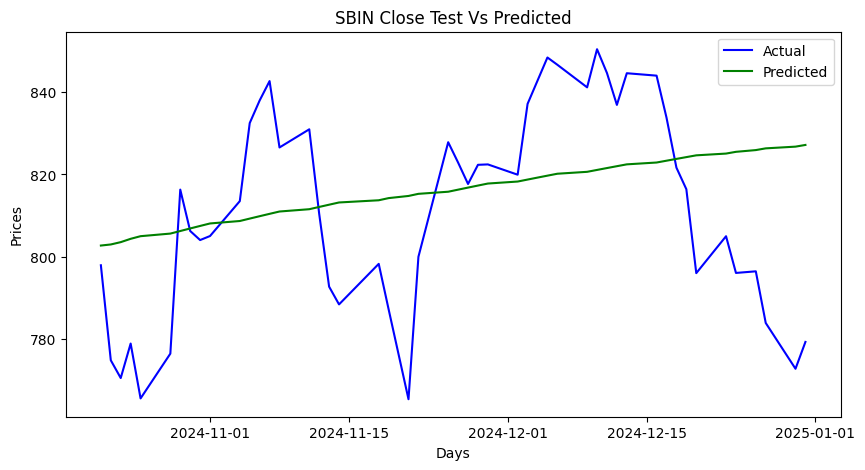

In [8]:
from stockFunctions import graph
graph(test_data['Close'], actual_y_pred_df, "Actual", "Predicted", "SBIN Close Test Vs Predicted", "Days", "Prices")


In [9]:
from stockFunctions import rmsemape
rmse, mape = rmsemape(test_data['Close'], actual_y_pred_df)
print(f'RMSE : {rmse:.4f} \nMaPe : {mape:.4f}')


RMSE : 24.1229 
MaPe : 0.0250


In [10]:
forecast = model_fit.predict(len(stk_data), len(stk_data)+3)
forecast


array([0.80210136, 0.80344516, 0.80478088, 0.80610875])

In [11]:
forecast_df = pd.DataFrame(forecast, columns=['Close_Forecast'])
actual_forecast = min_scale.inverse_transform(forecast_df)
actual_forecast_df = pd.DataFrame(actual_forecast, columns=['Close_Forecast'])
actual_forecast_df


,Close_Forecast
0,827.579131
1,827.988209
2,828.394826
3,828.799051


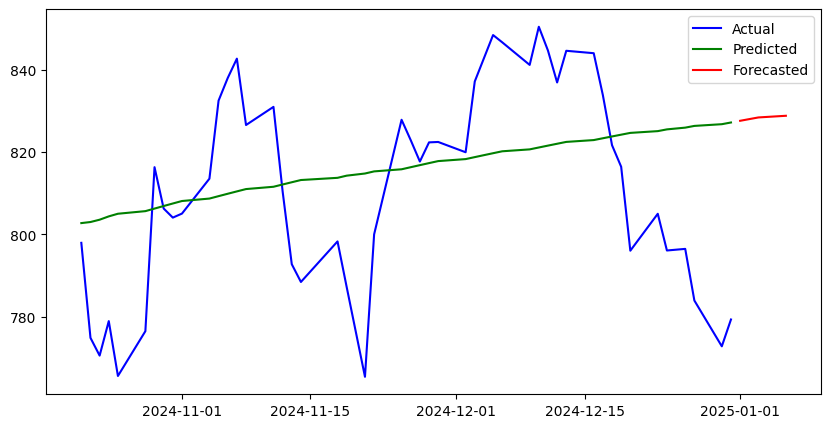

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(test_data['Close'], color = 'blue', label="Actual")
plt.plot(actual_y_pred_df, color = 'green', label="Predicted")

# Forecast starts AFTER last date
forecast_index = pd.date_range(
    start=test_data.index[-1] + pd.Timedelta(days=1),
    periods=len(actual_forecast_df),
    freq='B'
)

plt.plot(forecast_index, actual_forecast_df, color = 'red', label="Forecasted")

plt.legend()
plt.show()
